In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob

DATA_PATH = r"C:\Users\CyrilCorp\PyCharmMiscProject\ids-iot-combined\data\raw\ciciomt2024\train"

files = glob.glob(os.path.join(DATA_PATH, "*.csv"))
print(f"Found {len(files)} files")

dfs = []
for f in files:
    temp = pd.read_csv(f, low_memory=False)
    # Extract label from filename e.g. "Benign_train.pcap.csv" → "Benign"
    label = os.path.basename(f).replace("_train.pcap.csv", "")
    temp['label'] = label
    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nLabel distribution:")
print(df['label'].value_counts())

In [ ]:
# ── Basic info ────────────────────────────────────────────────────────────
print(f"Total rows: {len(df):,}")
print(f"Total columns: {len(df.columns)}")
print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum():,}")
print(f"\nData types:")
print(df.dtypes.value_counts())
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

# Binary label
df['binary_label'] = (df['label'] != 'Benign').astype(int)
print(f"\nBinary label distribution:")
print(df['binary_label'].value_counts())
print(f"Attack ratio: {df['binary_label'].mean():.1%}")

After dedup: 7,155,712 rows
Downsampled shape: (500000, 47)

Binary label distribution after sampling:
binary_label
1    486533
0     13467
Name: count, dtype: int64


C:\Users\CyrilCorp\AppData\Local\Temp\ipykernel_83900\4251865683.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=attack_counts.values, y=attack_counts.index, palette='Purples_r')


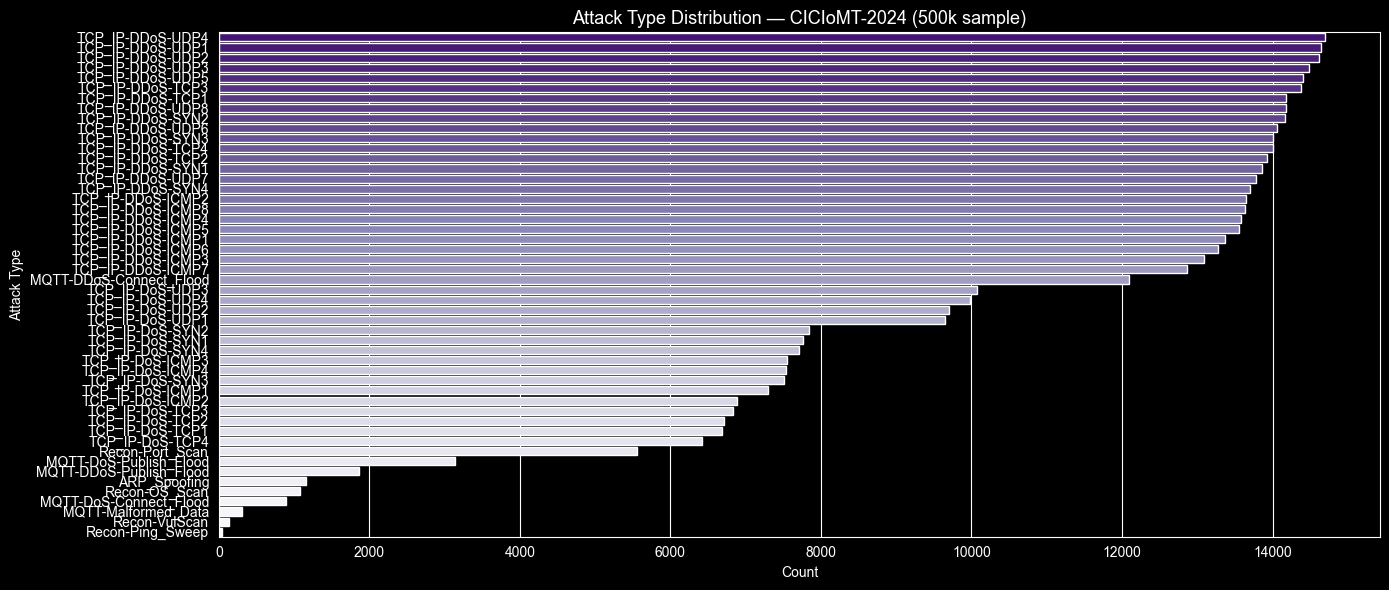

Saved attack distribution plot
Saved: ciciomt2024_sampled.csv


In [7]:
# ── Clean and downsample ──────────────────────────────────────────────────
from sklearn.utils import resample

# Drop duplicates
df = df.drop_duplicates()
print(f"After dedup: {len(df):,} rows")

# Downsample to 500k stratified
df_sampled = resample(df, n_samples=500000, random_state=42, stratify=df['binary_label'])
print(f"Downsampled shape: {df_sampled.shape}")
print(f"\nBinary label distribution after sampling:")
print(df_sampled['binary_label'].value_counts())

# Attack distribution plot
plt.figure(figsize=(14, 6))
attack_counts = df_sampled[df_sampled['binary_label'] == 1]['label'].value_counts()
sns.barplot(x=attack_counts.values, y=attack_counts.index, palette='Purples_r')
plt.title('Attack Type Distribution — CICIoMT-2024 (500k sample)', fontsize=13)
plt.xlabel('Count')
plt.ylabel('Attack Type')
plt.tight_layout()

RESULTS = r"C:\Users\CyrilCorp\PyCharmMiscProject\ids-iot-combined\results"
os.makedirs(RESULTS, exist_ok=True)
plt.savefig(os.path.join(RESULTS, "ciciomt2024_attack_dist.png"), dpi=150)
plt.show()
print("Saved attack distribution plot")

# Save sampled data
PROCESSED = r"C:\Users\CyrilCorp\PyCharmMiscProject\ids-iot-combined\data\processed"
df_sampled.to_csv(os.path.join(PROCESSED, "ciciomt2024_sampled.csv"), index=False)
print(f"Saved: ciciomt2024_sampled.csv")

In [4]:
print(df.columns.tolist())

['Header_Length', 'Protocol Type', 'Duration', 'Rate', 'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IGMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight']
